> TO DO

1. Inspect whether we can make use of some measure of sensitivity from totalistic CAs (and highlight how a general totalistic CA is different from the case we are studying here now).
2. Make a visual comparison of the jaggedness with some time evolution patterns

# Define jaggedness

In this notebook we will present progressively better definitions of "jaggedness" (actual name pending).

This is a measure that allows us to predict the way in which a defect may spread through a network, based on the LLNA's local update rule and the the networks' degree distribution.

## General principles

In the context of LLNAs, introducing a single defect has two effects:
1. The node that changes state will obey a different update rule
2. The nodes in the changed node's neighbourhood will experience a change in their neighbourhood's state density

These changes can have a big effect or a small effect on the dynamics of the system.

## The naive definition

In [2]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

In the first definition we only look at the effect of slightly modifying the local density. In particular we look at how many opportunities the LLNA has to change its output when a defect is introduced. We quantify this by counting the number of 'borders' in the diagram of the local update rule, dividing by the total possible number. Some examples are listed below:

In [124]:
def naive_jaggedness(resolution, B_set, S_set):
    ### value between 0 and 1
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    # perform XOR with shifted arrays
    borders_B = np.logical_xor(B_set_bin[1:], B_set_bin[:-1]).sum()
    borders_S = np.logical_xor(S_set_bin[1:], S_set_bin[:-1]).sum()
    # return total number of edges
    return (borders_B + borders_S)/(resolution-1)/2

resolution = 3
born_if = [0,1]
survive_if = [0,1]
naive_jaggedness(resolution, born_if, survive_if)

0.5

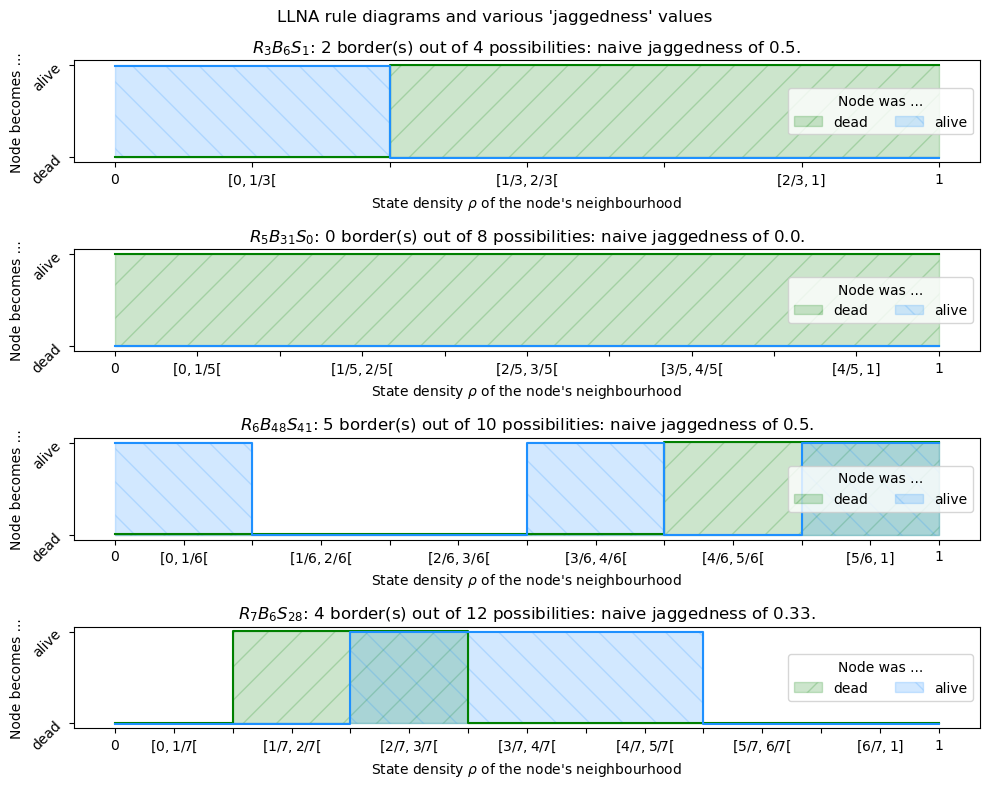

In [5]:
SAVEFIG=False

fig, axs = plt.subplots(4,1,figsize=(10, 8))

resolution = 3
born_if = [1, 2]
survive_if = [0]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[0].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

resolution = 5
born_if = [0, 1, 2, 3, 4]
survive_if = []
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[1].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

resolution = 6
born_if = [4, 5]
survive_if = [0, 3, 5]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[2])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[2].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

resolution = 7
born_if = [1, 2]
survive_if = [2, 3, 4]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[3])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[3].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

fig.suptitle("LLNA rule diagrams and various 'jaggedness' values")
fig.tight_layout()

Note:
1. We do not count the outer borders (those at $\rho = 0$ and $\rho = 1$) because they cannot be crossed.
2. The $B$ set has the same number of edges as the $B^\text{C}$ set, so the representation in the diagram does not matter.
3. There are always $2(R-1)$ possible borders.
4. There are more possibilities with an average number of borders than with a low or high number of borders.

## Add notion of changing the central node

If the central node is perturbed, the neighbourhood density is not altered, but the dynamical outcome may of course change as well. This is expressed by looking at some kind of XOR operation between the survive set and the born set. Again this value is normalised over the maximum (which is simply the resolution).

In [6]:
def naive_jaggedness_central_node(resolution, B_set, S_set):
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    borders = np.logical_xor(B_set_bin, S_set_bin).sum()
    return borders / resolution

In this spirit, the LLNA that can maximally change the outcome is the one that is the most jagged, and for which the born set is the complement of the survive set, for example

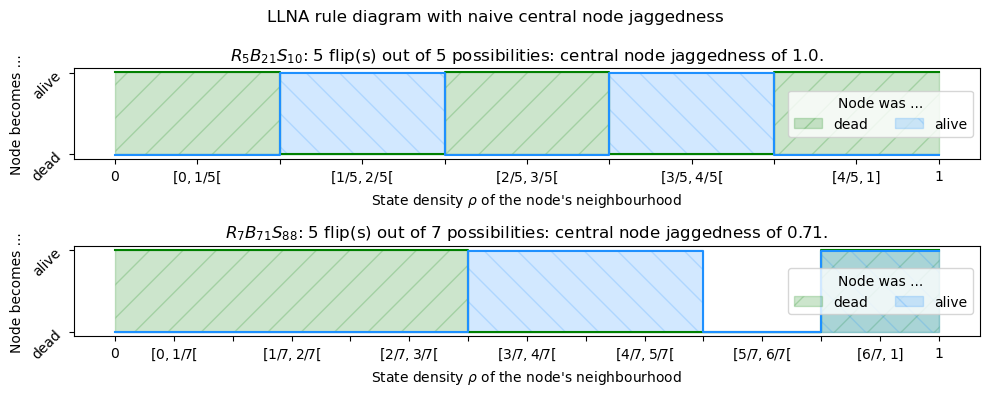

In [7]:
SAVEFIG=False

fig, axs = plt.subplots(2,1,figsize=(10, 4))

resolution = 5
born_if = [0, 2, 4]
survive_if = [1, 3]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
j = naive_jaggedness_central_node(resolution, born_if, survive_if)
flips = int(j*resolution)
axs[0].set_title(f"{model.__str__(latex=True)}: {flips} flip(s) out of {resolution} possibilities: central node jaggedness of {round(j,2)}.")

resolution = 7
born_if = [0, 1, 2, 6]
survive_if = [3, 4, 6]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
j = naive_jaggedness_central_node(resolution, born_if, survive_if)
flips = int(j*resolution)
axs[1].set_title(f"{model.__str__(latex=True)}: {flips} flip(s) out of {resolution} possibilities: central node jaggedness of {round(j,2)}.")

fig.suptitle("LLNA rule diagram with naive central node jaggedness")
fig.tight_layout()

It is not a priori clear how we should balance these two effects: the effect of changing the neighbourhood density, and the effect of changing the central node state. Some observations include:
1. Changing the state of the central node will always have the same effect; it is not depedent on the density of the local neighbourhood (and hence not dependent on the node degree)
2. LLNAs for which the 'central node jaggedness' is low and the 'naive jaggedness' is high, will generally not be very affected by introducing a defect. It is not clear, however, how important these definitions are compared to one another.
3. For isomorphic LLNAs, values from both jaggedness definitions are unchanged under an isomorphism

Also, a single jaggedness value is associated with a varying number of LLNAs. That is to say ...

_naive jaggedness definition_
- no borders: only one choice of border placement
- one border: $R-1$ choices
- two borders: $(R-1)(R-2)/2$ choices
- three borders: $(R-1)(R-2)(R-3)/6$ choices
- $N$ borders: $\prod_{i=1}^N(R-i)/i = \binom{R-1}{N}$ choices

Each of these border choices allows for two choices of intervals (either enabled or disabled). Summing all these possiblities, we find
$$
\left(2\sum_{N=0}^{R-1}\binom{R-1}{N}\right)^2 = \left(2 \times 2^{R-1}\right)^2 = 2^{2R},
$$
as required from the LLNA definition.

_central node jaggedness definition_
- zero central node jaggedness: all blocks must be identical: $2^R$ possible choices
- $1/R$ central node jaggedness: all-but-one blocks must be identical: $2^R R$ possible choices
- $2/R$ central node jaggedness: all-but-two blocks must be identical: $2^R R (R-1)/2$ possible choices
- $k/R$ central node jaggedness: all-but-$k$ blocks must be identical: $2^R R!/(R-k)!/k!$ possible choices

This again sums to a total of $2^{2R}$ choices, as required.

There does not seem to be an a priori reason to relate both jaggedness definitions. Let's inspect whether there is some correlation.

In [ ]:
def base_repr_padded(integer, resolution):
    int_binary = np.base_repr(integer, base=2)
    int_binary = '0'*(resolution-len(int_binary)) + int_binary
    return int_binary

# TODO there is definitely a nicer way to do this! That's not really the point here though
def int_to_set(integer, resolution):
    if integer >= 2**resolution:
        raise Exception(f"The value of the integer encoding the density intervals should not exceed {2**resolution-1}.")
    intervals = list(range(resolution))
    density_set = []
    brp = base_repr_padded(integer, resolution)
    for i, char in enumerate(brp[::-1]):
        if char=='1':
            density_set.append(i)
    return np.array(density_set)

Check whether the values of the naive jaggedness and the central-node jaggedness are independent, as they should be.

In [47]:
resolution = 8 # the higher, the (exponentially) more time it takes to calculate
B_sets = [int_to_set(integer, resolution) for integer in range(2**resolution)]
S_sets = B_sets.copy()

naive_js = []
naive_js_cn = []
for B_set in B_sets:
    for S_set in S_sets:
        naive_js += [naive_jaggedness(resolution, B_set, S_set)]
        naive_js_cn += [naive_jaggedness_central_node(resolution, B_set, S_set)]

# the values are independent of each other, indeed!
from scipy.stats import pearsonr
pr = pearsonr(naive_js, naive_js_cn).statistic

print(f"The Pearson's R is {pr}. There is no correlation.")

The Pearson's R is 0.0. There is no correlation.


Now let us see how the values of the jaggedness can be grouped, based on the size of the sets.

In [150]:
import itertools

# sets to choose from (two sets are identical)
resolution = 8
R_set = np.arange(resolution)

# Collect all valid combinations of two sets
j_values_per_total_size = []
j_values_cn_per_total_size = []
total_sizes = range(2*resolution+1)
for total_size in total_sizes:
    j_values = []
    j_values_cn = []
    for k in range(total_size + 1):  # k = number of elements from set1
        if k <= resolution and total_size - k <= resolution:
            # Combinations from set of density intervals
            B_sets = list(itertools.combinations(R_set, k))
            S_sets = list(itertools.combinations(R_set, total_size - k))
            # iterate over combinations of both sets that sum to total_size
            for B_set in B_sets:
                for S_set in S_sets:
                    j_value = naive_jaggedness(resolution, B_set, S_set)
                    j_value_cn = naive_jaggedness_central_node(resolution, B_set, S_set)
                    j_values.append(j_value)
                    j_values_cn.append(j_value_cn)
    j_values_per_total_size.append(j_values)
    j_values_cn_per_total_size.append(j_values_cn)

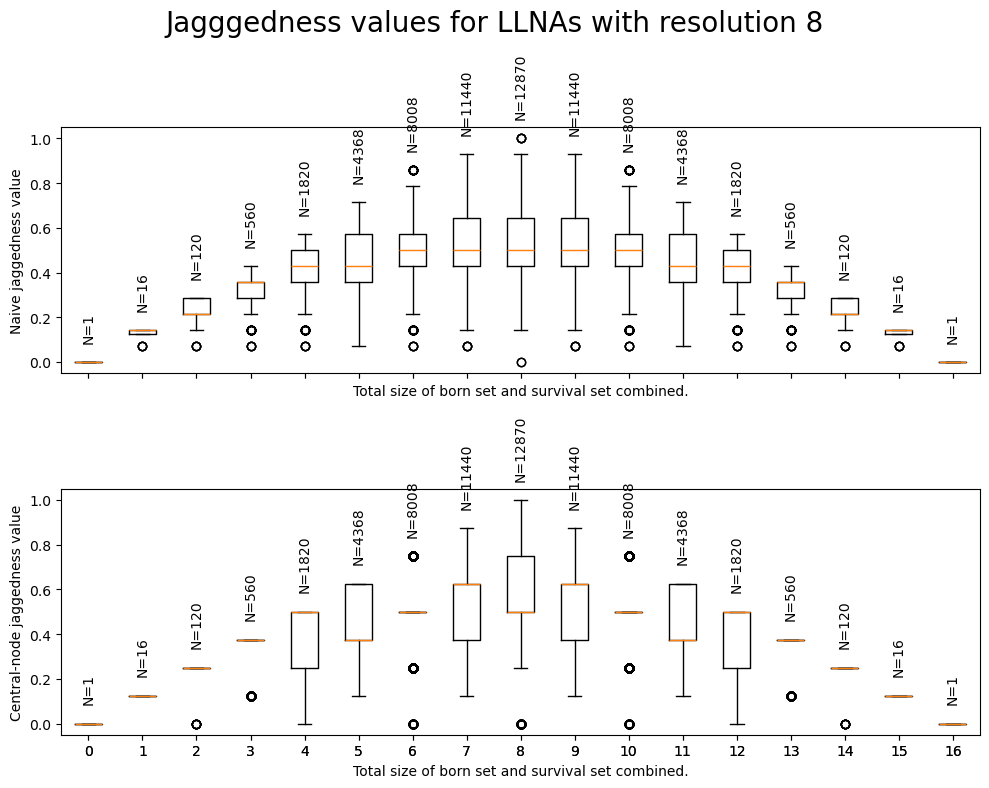

In [162]:
fig, axs = plt.subplots(2,1,figsize=(10,8), sharex=True)
axs[0].boxplot(j_values_per_total_size, tick_labels=total_sizes)
axs[1].boxplot(j_values_cn_per_total_size, tick_labels=total_sizes)
for ax in axs:
    ax.set_xlabel(f"Total size of born set and survival set combined.")
axs[0].set_ylabel("Naive jaggedness value")
axs[1].set_ylabel("Central-node jaggedness value")

# Annotate with the number of data points
for i, (dataset1, dataset2) in enumerate(zip(j_values_per_total_size, j_values_cn_per_total_size)):
    n1 = len(dataset1)  # Number of data points
    n2 = len(dataset2)
    axs[0].text(i + 1, max(dataset1) + 0.1, f'N={n1}', ha='center', fontsize=10, rotation=90)
    axs[1].text(i + 1, max(dataset2) + 0.1, f'N={n2}', ha='center', fontsize=10, rotation=90)

fig.suptitle(f"Jagggedness values for LLNAs with resolution {resolution}", size=20)
fig.tight_layout()

This shows the distribution of the values simply as a result of combinatorics. A complete and useful definition of jaggedness should probably take into account these combinatorial aspects, allowing for some kind of normalisation.

## Add weighing over degree distribution

Different levels of weighing:
1. Take into account the average node degree
2. Perform a weighted sum over all node degrees
3. Take into account that some densities are more common than others
4. Take into account that the density distribution changes over time